# Day 3 – Probability + Statistics
### 20-Day ML Revision Planner | Phase: Mathematical Foundation

**Topics covered:**
1. Probability & Conditional Probability
2. Independence
3. Random Variables
4. Bayes' Theorem
5. Expected Value, Variance, and Covariance
6. Descriptive Statistics (mean, median, mode, std, percentiles)
7. Normal Distribution & Z-score
8. Correlation
9. ML Connections (Naive Bayes, standardization, feature correlation)
10. Coding Practice on a Real Dataset
11. Interview Questions
12. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("NumPy:", np.__version__, "| Pandas:", pd.__version__)


NumPy: 2.4.4 | Pandas: 3.0.2


## 1. Probability & Conditional Probability

### What?
- **Probability** $P(A)$: a number between 0 and 1 representing how likely event $A$ is.
- **Conditional probability** $P(A \mid B)$: the probability of $A$ happening *given that* $B$ has already happened.

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

### Why?
Almost every ML classifier outputs a **conditional probability**: $P(\text{class} \mid \text{features})$. Understanding how evidence updates belief is foundational to probabilistic models (Naive Bayes, logistic regression's probabilistic interpretation, Bayesian methods).

### How?
- $P(A \cap B)$: probability that both $A$ and $B$ occur.
- Conditioning "shrinks" the sample space to only the cases where $B$ is true, then asks what fraction of those also satisfy $A$.


In [2]:
# Simulate rolling two dice to build intuition for joint/conditional probability
np.random.seed(1)
n_trials = 200_000
die1 = np.random.randint(1, 7, n_trials)
die2 = np.random.randint(1, 7, n_trials)

# Event A: sum of dice == 8
# Event B: first die == 5
event_A = (die1 + die2) == 8
event_B = (die1 == 5)

P_A = event_A.mean()
P_B = event_B.mean()
P_A_and_B = (event_A & event_B).mean()
P_A_given_B = P_A_and_B / P_B

print(f"P(A) [sum=8]           ≈ {P_A:.4f}  (theoretical: {5/36:.4f})")
print(f"P(B) [die1=5]          ≈ {P_B:.4f}  (theoretical: {1/6:.4f})")
print(f"P(A and B)             ≈ {P_A_and_B:.4f}")
print(f"P(A | B) [sum=8|die1=5]≈ {P_A_given_B:.4f}  (theoretical: 1/6 = {1/6:.4f}, since die2 must be 3)")


P(A) [sum=8]           ≈ 0.1407  (theoretical: 0.1389)
P(B) [die1=5]          ≈ 0.1669  (theoretical: 0.1667)
P(A and B)             ≈ 0.0281
P(A | B) [sum=8|die1=5]≈ 0.1685  (theoretical: 1/6 = 0.1667, since die2 must be 3)


## 2. Independence

### What?
Two events $A$ and $B$ are **independent** if knowing one occurred gives no information about the other:

$$P(A \mid B) = P(A) \quad \Longleftrightarrow \quad P(A \cap B) = P(A) \cdot P(B)$$

### Why?
Many ML algorithms make an independence assumption to simplify computation — most famously, **Naive Bayes** assumes features are conditionally independent given the class. Even though this assumption is often technically false, it works surprisingly well in practice and makes the math tractable.

### How?
Check whether $P(A \cap B) = P(A)P(B)$. If yes → independent. If $P(A \cap B) \neq P(A)P(B)$ → dependent.


In [3]:
# Independent example: two separate die rolls
event_die1_even = (die1 % 2 == 0)
event_die2_even = (die2 % 2 == 0)

P_1_even = event_die1_even.mean()
P_2_even = event_die2_even.mean()
P_both_even = (event_die1_even & event_die2_even).mean()

print("Independence check for two separate dice (should hold):")
print(f"P(die1 even) * P(die2 even) = {P_1_even:.4f} * {P_2_even:.4f} = {P_1_even * P_2_even:.4f}")
print(f"P(die1 even AND die2 even)   = {P_both_even:.4f}")
print("--> Very close, confirming independence (small deviation is just sampling noise).\n")

# Dependent example: event_A (sum=8) and event_B (die1=5) from before
print("Dependence check for sum=8 and die1=5 (should NOT hold):")
print(f"P(A) * P(B) = {P_A:.4f} * {P_B:.4f} = {P_A * P_B:.4f}")
print(f"P(A AND B)  = {P_A_and_B:.4f}")
print("--> These differ meaningfully, confirming A and B are dependent.")


Independence check for two separate dice (should hold):
P(die1 even) * P(die2 even) = 0.4991 * 0.5011 = 0.2501
P(die1 even AND die2 even)   = 0.2504
--> Very close, confirming independence (small deviation is just sampling noise).

Dependence check for sum=8 and die1=5 (should NOT hold):
P(A) * P(B) = 0.1407 * 0.1669 = 0.0235
P(A AND B)  = 0.0281
--> These differ meaningfully, confirming A and B are dependent.


## 3. Random Variables

### What?
A **random variable** (RV) is a variable whose value is the numerical outcome of a random phenomenon.
- **Discrete RV**: takes countable values (e.g., number of heads in 10 coin flips).
- **Continuous RV**: takes any value in a range (e.g., a person's height).

Each RV has a **probability distribution** describing how likely each value (or range of values) is.

### Why?
Every feature and every model output in ML can be thought of as a random variable — feature values sampled from some underlying (usually unknown) distribution, and model predictions being estimates of conditional expectations or probabilities.

### How?
- Discrete RVs are described by a **probability mass function (PMF)**: $P(X = x)$.
- Continuous RVs are described by a **probability density function (PDF)**: $f(x)$, where probability of a *range* is the area under the curve.


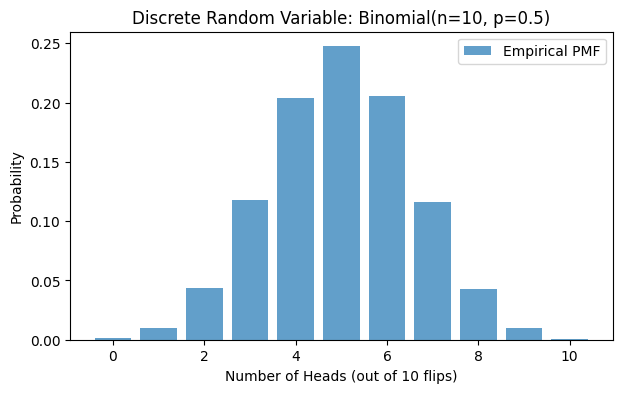

Most likely outcome: 5 heads
Mean number of heads (empirical): 4.99977 | theoretical (n*p): 5.0


In [4]:
# Discrete RV: number of heads in 10 fair coin flips (Binomial distribution)
n_flips = 10
p_heads = 0.5
n_experiments = 100_000

heads_counts = np.random.binomial(n_flips, p_heads, n_experiments)

values, counts = np.unique(heads_counts, return_counts=True)
pmf_empirical = counts / n_experiments

plt.figure(figsize=(7, 4))
plt.bar(values, pmf_empirical, alpha=0.7, label="Empirical PMF")
plt.xlabel("Number of Heads (out of 10 flips)")
plt.ylabel("Probability")
plt.title("Discrete Random Variable: Binomial(n=10, p=0.5)")
plt.legend()
plt.show()

print("Most likely outcome:", values[np.argmax(pmf_empirical)], "heads")
print("Mean number of heads (empirical):", heads_counts.mean(), "| theoretical (n*p):", n_flips * p_heads)


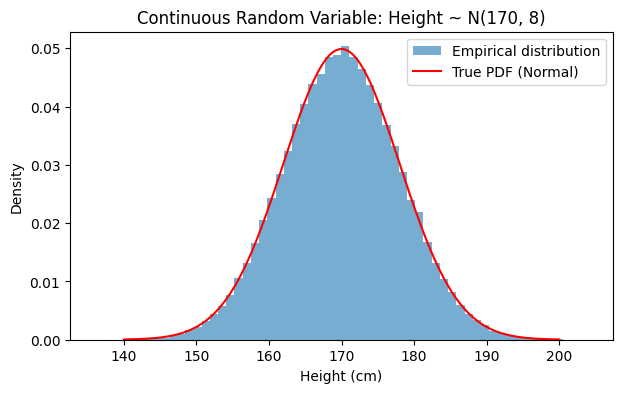

In [5]:
# Continuous RV: heights sampled from a Normal distribution
heights = np.random.normal(loc=170, scale=8, size=100_000)  # mean=170cm, std=8cm

plt.figure(figsize=(7, 4))
plt.hist(heights, bins=60, density=True, alpha=0.6, label="Empirical distribution")
x = np.linspace(140, 200, 300)
plt.plot(x, stats.norm.pdf(x, loc=170, scale=8), 'r-', label="True PDF (Normal)")
plt.xlabel("Height (cm)"); plt.ylabel("Density")
plt.title("Continuous Random Variable: Height ~ N(170, 8)")
plt.legend()
plt.show()


## 4. Bayes' Theorem

### What?
Bayes' theorem tells us how to **update our belief** about a hypothesis given new evidence:

$$P(A \mid B) = \frac{P(B \mid A) \, P(A)}{P(B)}$$

Where:
- $P(A)$ = **prior** — belief before seeing evidence
- $P(B \mid A)$ = **likelihood** — how probable the evidence is if $A$ is true
- $P(A \mid B)$ = **posterior** — updated belief after seeing evidence
- $P(B)$ = **evidence** (a normalizing constant)

### Why?
This is the mathematical foundation of the **Naive Bayes classifier**, and of Bayesian statistics/ML broadly — used in spam filtering, medical diagnosis, recommendation systems, and more.

### How?
Classic example — **medical testing**: even a highly accurate test can produce mostly false positives if the disease is rare. This is the single most common "gotcha" interview question about Bayes' theorem.


In [6]:
# Classic Bayes' theorem example: disease testing
# P(Disease) = 1% (prior)
# P(Positive | Disease) = 99% (test sensitivity / true positive rate)
# P(Positive | No Disease) = 5% (false positive rate)

P_disease = 0.01
P_pos_given_disease = 0.99
P_pos_given_no_disease = 0.05
P_no_disease = 1 - P_disease

# P(Positive) via the law of total probability
P_positive = P_pos_given_disease * P_disease + P_pos_given_no_disease * P_no_disease

# Bayes' theorem: P(Disease | Positive)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print(f"P(Disease)                = {P_disease:.2%}  (prior)")
print(f"P(Positive | Disease)     = {P_pos_given_disease:.2%}  (likelihood / sensitivity)")
print(f"P(Positive | No Disease)  = {P_pos_given_no_disease:.2%}  (false positive rate)")
print(f"P(Positive) [total prob]  = {P_positive:.4f}")
print(f"\nP(Disease | Positive)     = {P_disease_given_pos:.2%}  <-- posterior")
print("\n--> Even with a 99% accurate test, if you test positive, you only have a")
print("    ~16.7% chance of actually having the disease, because the disease is rare!")
print("    This is exactly why base rates (priors) matter so much in ML and diagnostics.")

# Verify via brute-force simulation
np.random.seed(2)
n_people = 2_000_000
has_disease = np.random.rand(n_people) < P_disease
test_positive = np.where(
    has_disease,
    np.random.rand(n_people) < P_pos_given_disease,
    np.random.rand(n_people) < P_pos_given_no_disease
)
sim_result = has_disease[test_positive].mean()
print(f"\nSimulation check: P(Disease | Positive) ≈ {sim_result:.4f}  (matches analytical result)")


P(Disease)                = 1.00%  (prior)
P(Positive | Disease)     = 99.00%  (likelihood / sensitivity)
P(Positive | No Disease)  = 5.00%  (false positive rate)
P(Positive) [total prob]  = 0.0594

P(Disease | Positive)     = 16.67%  <-- posterior

--> Even with a 99% accurate test, if you test positive, you only have a
    ~16.7% chance of actually having the disease, because the disease is rare!
    This is exactly why base rates (priors) matter so much in ML and diagnostics.

Simulation check: P(Disease | Positive) ≈ 0.1687  (matches analytical result)


## 5. Expected Value, Variance, and Covariance

### What?
- **Expected value** $E[X]$: the long-run average value of a random variable (weighted by probability).
  $$E[X] = \sum_i x_i P(x_i) \quad \text{(discrete)}, \qquad E[X] = \int x f(x)\,dx \quad \text{(continuous)}$$
- **Variance** $\text{Var}(X)$: how spread out the values of $X$ are around the mean.
  $$\text{Var}(X) = E[(X - E[X])^2]$$
- **Covariance** $\text{Cov}(X, Y)$: how two variables change *together*.
  $$\text{Cov}(X, Y) = E[(X - E[X])(Y - E[Y])]$$

### Why?
- Expected value underlies loss functions (e.g., expected loss over the data distribution) and metrics like mean squared error.
- Variance is central to the **bias-variance tradeoff** — a model with high variance overfits, memorizing noise.
- Covariance (and its normalized form, correlation) tells us whether features move together, which matters for feature selection and multicollinearity (recall Day 1's rank discussion).

### How?
- Positive covariance: as $X$ increases, $Y$ tends to increase too.
- Negative covariance: as $X$ increases, $Y$ tends to decrease.
- Covariance near zero: little to no linear relationship.


Expected value of a fair die roll: 3.5
Variance of a fair die roll: 2.9167

Covariance matrix (hours studied vs exam score):
 [[  4.1929  33.2414]
 [ 33.2414 288.2487]]
Cov(hours, score) = 33.24 --> positive, they move together


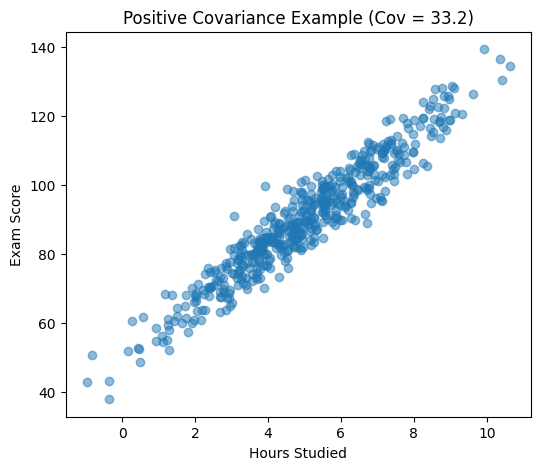

In [7]:
# Expected value and variance for a discrete RV (dice roll)
outcomes = np.array([1, 2, 3, 4, 5, 6])
probs = np.array([1/6] * 6)

E_X = np.sum(outcomes * probs)
Var_X = np.sum(((outcomes - E_X)**2) * probs)

print("Expected value of a fair die roll:", E_X)
print("Variance of a fair die roll:", round(Var_X, 4))

# Covariance between two variables
np.random.seed(3)
hours_studied = np.random.normal(5, 2, 500)
exam_score = 50 + 8 * hours_studied + np.random.normal(0, 5, 500)  # positively related

cov_matrix = np.cov(hours_studied, exam_score)
print("\nCovariance matrix (hours studied vs exam score):\n", cov_matrix)
print("Cov(hours, score) =", round(cov_matrix[0, 1], 2), "--> positive, they move together")

plt.figure(figsize=(6, 5))
plt.scatter(hours_studied, exam_score, alpha=0.5)
plt.xlabel("Hours Studied"); plt.ylabel("Exam Score")
plt.title(f"Positive Covariance Example (Cov = {cov_matrix[0,1]:.1f})")
plt.show()


## 6. Descriptive Statistics: Mean, Median, Mode, Variance, Std, Percentiles

### What?
- **Mean**: arithmetic average — sensitive to outliers.
- **Median**: middle value when sorted — robust to outliers.
- **Mode**: most frequent value.
- **Standard deviation**: $\sqrt{\text{Variance}}$ — spread in the *same units* as the data (unlike variance, which is squared units).
- **Percentile**: the value below which a given percentage of observations fall (e.g., the 90th percentile is higher than 90% of the data).

### Why?
These are the very first things you compute during **EDA (Exploratory Data Analysis)** to understand a dataset's central tendency, spread, and shape before modeling — and to spot outliers or skew that could hurt a model.

### How?
- If mean ≫ median → right-skewed distribution (long tail of high values, e.g. income data).
- If mean ≪ median → left-skewed distribution.
- If mean ≈ median → roughly symmetric distribution.


In [8]:
# Load a real dataset for hands-on statistics practice: sklearn's California Housing (or a built-in fallback)
from sklearn.datasets import fetch_california_housing

try:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    print("Loaded California Housing dataset:", df.shape)
except Exception as e:
    print("Falling back to a synthetic dataset (no internet access):", e)
    np.random.seed(7)
    df = pd.DataFrame({
        'MedInc': np.random.gamma(5, 1.5, 2000),
        'HouseAge': np.random.uniform(1, 52, 2000),
        'AveRooms': np.random.normal(5.5, 1.2, 2000),
        'Population': np.random.exponential(1200, 2000),
        'MedHouseVal': np.random.gamma(4, 0.6, 2000),
    })

df.head()


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Falling back to a synthetic dataset (no internet access): HTTP Error 403: Forbidden


,MedInc,HouseAge,AveRooms,Population,MedHouseVal
0,14.0311,40.1727,5.5682,38.1069,1.7413
1,5.5961,10.6711,5.8378,1640.2172,4.1018
2,4.7422,24.0993,5.3660,166.5888,3.7937
3,7.0067,2.0202,3.6971,2578.5335,2.8366
4,10.8425,43.2821,5.2027,1201.8081,1.2077


In [9]:
# Descriptive statistics using Pandas
desc_stats = df.describe().T
desc_stats['median'] = df.median()
desc_stats['mode'] = df.mode().iloc[0]
print(desc_stats[['mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', 'max']])


                  mean    median    mode        std     min       25%  \
MedInc          7.4345    6.9742  0.7405     3.3163  0.7405    5.0581   
HouseAge       26.4402   26.3868  1.0058    14.8504  1.0058   13.3687   
AveRooms        5.4970    5.4832  1.6160     1.1683  1.6160    4.7111   
Population   1192.4539  822.7177  0.0632  1189.9776  0.0632  309.3643   
MedHouseVal     2.4116    2.2451  0.1920     1.1770  0.1920    1.5452   

                  50%        75%        max  
MedInc         6.9742     9.3693    27.4815  
HouseAge      26.3868    39.7181    51.9916  
AveRooms       5.4832     6.2960     9.5684  
Population   822.7177  1656.1748  9191.0784  
MedHouseVal    2.2451     3.0547     8.6815  


Column analyzed: 'MedHouseVal'
Mean:   2.4116
Median: 2.2451
Mode:   0.1920
--> Mean > Median: distribution is likely RIGHT-skewed (long tail of high values).


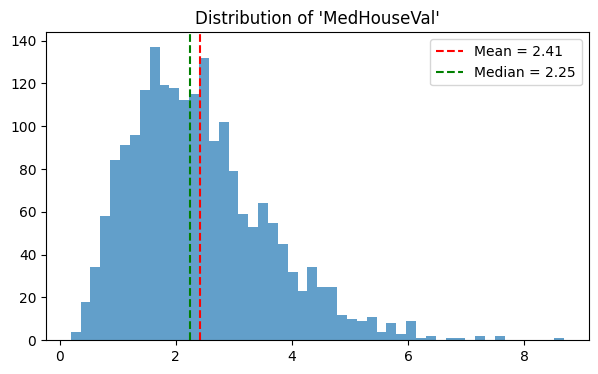


Percentiles:
  10th percentile: 1.0456
  25th percentile: 1.5452
  50th percentile: 2.2451
  75th percentile: 3.0547
  90th percentile: 4.0162
  99th percentile: 5.8915


In [10]:
# Mean vs Median comparison to detect skew (using the target/value column)
target_col = df.columns[-1]
col_data = df[target_col]

mean_val = col_data.mean()
median_val = col_data.median()
mode_val = col_data.mode()[0]

print(f"Column analyzed: '{target_col}'")
print(f"Mean:   {mean_val:.4f}")
print(f"Median: {median_val:.4f}")
print(f"Mode:   {mode_val:.4f}")

if mean_val > median_val * 1.05:
    print("--> Mean > Median: distribution is likely RIGHT-skewed (long tail of high values).")
elif mean_val < median_val * 0.95:
    print("--> Mean < Median: distribution is likely LEFT-skewed.")
else:
    print("--> Mean ≈ Median: distribution is roughly symmetric.")

plt.figure(figsize=(7, 4))
plt.hist(col_data, bins=50, alpha=0.7)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median = {median_val:.2f}')
plt.legend(); plt.title(f"Distribution of '{target_col}'")
plt.show()

# Percentiles
percentiles = [10, 25, 50, 75, 90, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th percentile: {np.percentile(col_data, p):.4f}")


## 7. Normal Distribution & Z-score

### What?
- The **Normal (Gaussian) distribution** is a symmetric, bell-shaped distribution defined by mean $\mu$ and standard deviation $\sigma$:
  $$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$
- The **Z-score** standardizes a value by expressing it in terms of "how many standard deviations away from the mean":
  $$z = \frac{x - \mu}{\sigma}$$

### Why?
- Many statistical tests and ML assumptions rely on (approximate) normality.
- Z-scores are the basis of **standardization** (a critical preprocessing step, seen again on Day 4) and are used to detect **outliers** (commonly, $|z| > 3$ is flagged as an outlier).
- The **68-95-99.7 rule**: ~68% of data falls within 1 std of the mean, ~95% within 2 std, ~99.7% within 3 std — useful for quick sanity checks.

### How?
Compute mean and std, then transform each value using the z-score formula.


Mean: 50.58, Std: 10.39
Number of outliers (|z| > 3): 3
Outlier values: [120. -30. 130.]


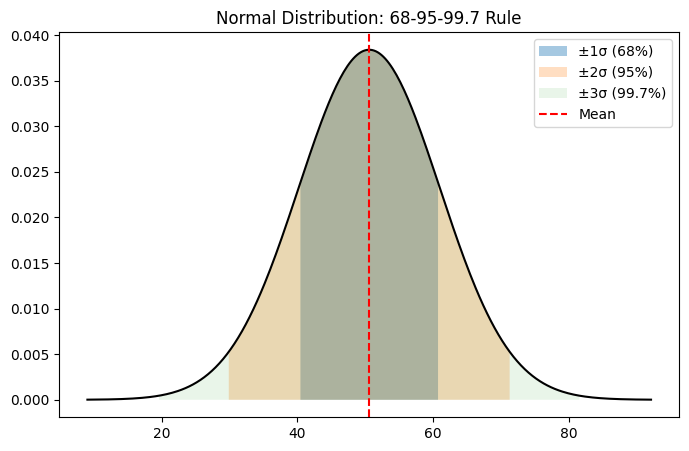

In [11]:
# Z-score standardization and outlier detection
np.random.seed(4)
data = np.random.normal(50, 10, 1000)
# Inject a few outliers
data = np.concatenate([data, [120, -30, 130]])

mean, std = data.mean(), data.std()
z_scores = (data - mean) / std

outliers = data[np.abs(z_scores) > 3]
print(f"Mean: {mean:.2f}, Std: {std:.2f}")
print(f"Number of outliers (|z| > 3): {len(outliers)}")
print("Outlier values:", outliers)

# Visualize the 68-95-99.7 rule
x = np.linspace(mean - 4*std, mean + 4*std, 300)
y = stats.norm.pdf(x, mean, std)

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='black')
for k, alpha, label in [(1, 0.4, '68%'), (2, 0.25, '95%'), (3, 0.1, '99.7%')]:
    plt.fill_between(x, y, where=(np.abs(x - mean) <= k*std), alpha=alpha, label=f'±{k}σ ({label})')
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.legend(); plt.title("Normal Distribution: 68-95-99.7 Rule")
plt.show()


## 8. Correlation

### What?
**Correlation** measures the **strength and direction** of the *linear* relationship between two variables, normalized to always fall between -1 and 1:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$$

- $r = 1$: perfect positive linear relationship
- $r = -1$: perfect negative linear relationship
- $r = 0$: no linear relationship (there could still be a non-linear one!)

### Why?
- Used for **feature selection**: highly correlated features with the target are often predictive; highly correlated features with *each other* signal redundancy (multicollinearity, tying back to Day 1's rank discussion).
- Correlation heatmaps are a standard first step in EDA.

### How?
`df.corr()` in Pandas computes pairwise Pearson correlation for all numeric columns.

⚠️ **Correlation ≠ Causation**, and correlation only captures *linear* relationships — two variables can be strongly related non-linearly while having a correlation near 0.


             MedInc  HouseAge  AveRooms  Population  MedHouseVal
MedInc         1.00     -0.02      0.01       -0.04        -0.01
HouseAge      -0.02      1.00      0.01       -0.01        -0.00
AveRooms       0.01      0.01      1.00       -0.06         0.02
Population    -0.04     -0.01     -0.06        1.00         0.01
MedHouseVal   -0.01     -0.00      0.02        0.01         1.00


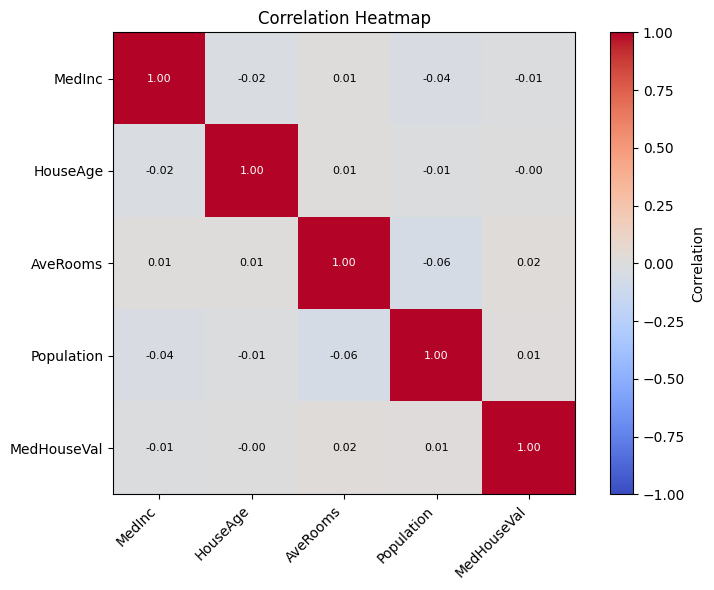

In [12]:
# Correlation matrix and heatmap on the real dataset
corr_matrix = df.corr()
print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center',
                  color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black', fontsize=8)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


Pearson correlation between x and x^2 (+ noise): 0.0051
--> Despite a very strong (deterministic) relationship, Pearson correlation is near 0,
    because the relationship is non-linear, not linear. Always visualize your data!


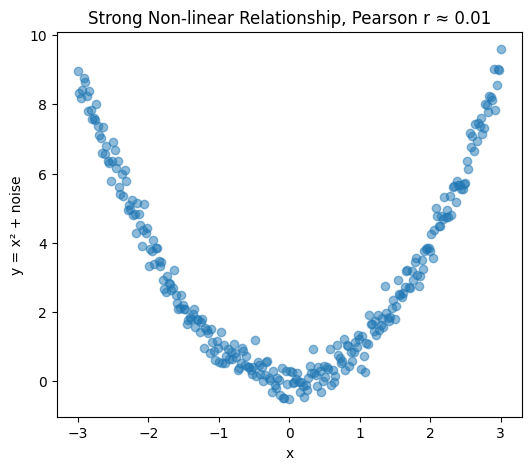

In [13]:
# Correlation vs causation / linear vs non-linear demo
x_nl = np.linspace(-3, 3, 300)
y_nl = x_nl ** 2 + np.random.normal(0, 0.3, 300)   # strong non-linear (quadratic) relationship

pearson_r = np.corrcoef(x_nl, y_nl)[0, 1]
print(f"Pearson correlation between x and x^2 (+ noise): {pearson_r:.4f}")
print("--> Despite a very strong (deterministic) relationship, Pearson correlation is near 0,")
print("    because the relationship is non-linear, not linear. Always visualize your data!")

plt.figure(figsize=(6, 5))
plt.scatter(x_nl, y_nl, alpha=0.5)
plt.title(f"Strong Non-linear Relationship, Pearson r ≈ {pearson_r:.2f}")
plt.xlabel("x"); plt.ylabel("y = x² + noise")
plt.show()


## 9. ML Connection Recap

| Concept | ML Usage |
|---|---|
| Conditional probability | Classifier outputs: $P(\text{class} \mid \text{features})$ |
| Independence assumption | Naive Bayes classifier |
| Bayes' theorem | Naive Bayes, Bayesian inference, spam filtering |
| Expected value | Loss functions (expected loss over data distribution) |
| Variance | Bias-variance tradeoff, model stability |
| Z-score / standardization | Feature scaling before training (esp. for distance-based & gradient-based models) |
| Correlation | Feature selection, detecting multicollinearity |
| Normal distribution | Assumption behind many statistical tests, initialization schemes, and confidence intervals |


In [14]:
# Mini implementation: Gaussian Naive Bayes "by hand" to tie everything together
# We estimate P(class), and per-feature mean/std per class, then use Bayes' theorem
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

class GaussianNBScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        self.means = {}
        self.stds = {}
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = X_c.shape[0] / X.shape[0]     # P(class)
            self.means[c] = X_c.mean(axis=0)
            self.stds[c] = X_c.std(axis=0) + 1e-9            # avoid div-by-zero

    def _gaussian_likelihood(self, x, mean, std):
        # Normal PDF, applied feature-wise then multiplied (naive independence assumption)
        exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        return (1 / (std * np.sqrt(2 * np.pi))) * exponent

    def predict(self, X):
        preds = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                likelihood = np.prod(self._gaussian_likelihood(x, self.means[c], self.stds[c]))
                posteriors[c] = self.priors[c] * likelihood   # Bayes' theorem (unnormalized)
            preds.append(max(posteriors, key=posteriors.get))
        return np.array(preds)

# Train/test split
np.random.seed(5)
idx = np.random.permutation(len(X_iris))
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

nb_scratch = GaussianNBScratch()
nb_scratch.fit(X_iris[train_idx], y_iris[train_idx])
preds = nb_scratch.predict(X_iris[test_idx])

accuracy = (preds == y_iris[test_idx]).mean()
print(f"Scratch Gaussian Naive Bayes accuracy on Iris test set: {accuracy:.2%}")

# Compare with sklearn's implementation
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB()
sk_nb.fit(X_iris[train_idx], y_iris[train_idx])
sk_accuracy = sk_nb.score(X_iris[test_idx], y_iris[test_idx])
print(f"sklearn GaussianNB accuracy:                          {sk_accuracy:.2%}")


Scratch Gaussian Naive Bayes accuracy on Iris test set: 96.67%


sklearn GaussianNB accuracy:                          96.67%


## 10. Coding Practice — Standalone Exercises

Try these before checking the outputs above:


In [15]:
# Exercise 1: Compute mean, median, std "from scratch" without numpy built-ins for a raw list
def mean_scratch(values):
    return sum(values) / len(values)

def median_scratch(values):
    sorted_vals = sorted(values)
    n = len(sorted_vals)
    mid = n // 2
    if n % 2 == 0:
        return (sorted_vals[mid - 1] + sorted_vals[mid]) / 2
    return sorted_vals[mid]

def std_scratch(values):
    m = mean_scratch(values)
    variance = sum((x - m) ** 2 for x in values) / len(values)
    return variance ** 0.5

sample = [12, 15, 12, 18, 22, 9, 30, 15, 20]
print("Mean (scratch):", mean_scratch(sample), "| numpy:", np.mean(sample))
print("Median (scratch):", median_scratch(sample), "| numpy:", np.median(sample))
print("Std (scratch):", round(std_scratch(sample), 4), "| numpy:", round(np.std(sample), 4))


Mean (scratch): 17.0 | numpy: 17.0
Median (scratch): 15 | numpy: 15.0
Std (scratch): 6.0185 | numpy: 6.0185


In [16]:
# Exercise 2: Z-score standardize a column and flag outliers beyond |z| > 2.5
def z_score_standardize(values):
    values = np.array(values, dtype=float)
    return (values - values.mean()) / values.std()

sample2 = np.array([10, 12, 11, 13, 9, 100, 12, 11, 10, -50])
z = z_score_standardize(sample2)
print("Z-scores:", np.round(z, 2))
outlier_mask = np.abs(z) > 2.5
print("Flagged outliers:", sample2[outlier_mask])


Z-scores: [-0.11 -0.05 -0.08 -0.02 -0.14  2.53 -0.05 -0.08 -0.11 -1.88]
Flagged outliers: [100]


In [17]:
# Exercise 3: Compute Pearson correlation from scratch and compare to np.corrcoef
def pearson_corr_scratch(x, y):
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    x_dev = x - x.mean()
    y_dev = y - y.mean()
    numerator = np.sum(x_dev * y_dev)
    denominator = np.sqrt(np.sum(x_dev**2)) * np.sqrt(np.sum(y_dev**2))
    return numerator / denominator

x_ex = df[df.columns[0]].values[:200]
y_ex = df[df.columns[-1]].values[:200]

r_scratch = pearson_corr_scratch(x_ex, y_ex)
r_numpy = np.corrcoef(x_ex, y_ex)[0, 1]
print(f"Scratch Pearson r: {r_scratch:.4f}")
print(f"NumPy Pearson r:   {r_numpy:.4f}")
assert np.isclose(r_scratch, r_numpy)
print("Matches ✔")


Scratch Pearson r: 0.0660
NumPy Pearson r:   0.0660
Matches ✔


## 11. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Explain Bayes' theorem in plain English, with an example.**
   *Hint: use the disease-testing example — emphasize how the prior (base rate) affects the posterior.*

2. **What's the difference between correlation and covariance?**
   *Hint: correlation is covariance normalized by the standard deviations, so it's unitless and bounded in [-1, 1].*

3. **Why does Naive Bayes assume feature independence, and is that assumption realistic?**
   *Hint: simplifies the joint likelihood into a product of per-feature likelihoods; often false in practice but works well anyway.*

4. **What does a Z-score tell you, and how is it used to detect outliers?**
   *Hint: number of standard deviations from the mean; commonly |z| > 3 flags an outlier.*

5. **(Bonus) Can two variables have zero correlation but still be strongly related? Give an example.**
   *Hint: yes — non-linear relationships (e.g., $y = x^2$) can have near-zero Pearson correlation.*

6. **(Bonus) Why is standardization (z-score scaling) important before training some ML models but not others?**
   *Hint: distance-based (KNN, K-Means) and gradient-based models are sensitive to feature scale; tree-based models are not.*


## 12. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] State the formula for conditional probability and explain it in words.
- [ ] Explain independence and how it relates to the Naive Bayes assumption.
- [ ] State Bayes' theorem from memory and identify the prior, likelihood, posterior, and evidence terms.
- [ ] Explain expected value and variance, and connect variance to the bias-variance tradeoff.
- [ ] Compute mean, median, mode, std, and percentiles for a dataset and interpret skew from mean vs median.
- [ ] Explain the Z-score formula and the 68-95-99.7 rule.
- [ ] Explain correlation, its range, and why correlation ≠ causation and only captures linear relationships.
- [ ] Implement Gaussian Naive Bayes from scratch and explain how Bayes' theorem is used in each prediction.

### 📌 Daily Output (per the planner)
A **probability + statistics formula sheet**, plus (as practiced in Section 10) hands-on computation of statistical quantities using NumPy/Pandas on a real dataset:
- Mean, median, mode, variance, std, percentiles
- Z-score standardization and outlier detection
- Correlation matrix and heatmap interpretation

Close this notebook and try to **re-derive Bayes' theorem and re-implement the scratch Naive Bayes classifier from memory** — that's the real test of Day 3 mastery.
